In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from quantumScarsCheck import *
from quantumScarsPlotting import *
from quantumScarFunctions import *

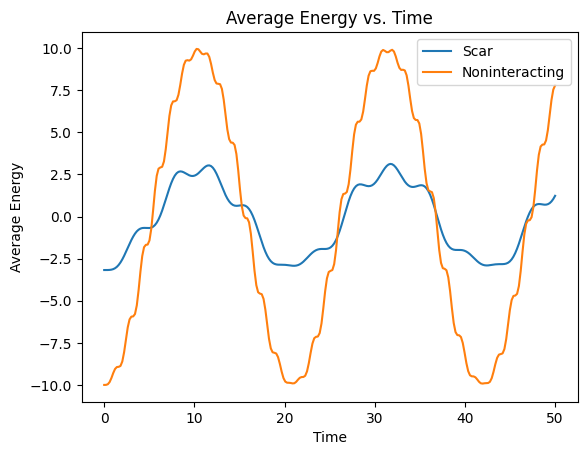

Scar Power: 0.14215134317300945
Qubit Power: 0.5737673635372995
Power Gap: 4.036313345551573
Basis Gap: 8.325203252032521


In [6]:
N = 10
tlist = np.linspace(0, 50, 250)

H0, H1, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
basisLen = len(basisList)
args = {"A": 0.3, "omega": 0.642570281124498}
H = qt.QobjEvo([H0, [H1, coeff]], args=args)
psi_t = qt.sesolve(H, eigenstates[0], tlist)

qH0, qH1 = get_qubit_ham(N)
qeigenvalues, qeigenstates = qH0.eigenstates()
qargs = {"A": 0.3, "omega": 2.0}
qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
qpsi_t = qt.sesolve(qH, qeigenstates[0], tlist)

expectationVals = []
qexpectationVals = []

for states in psi_t.states:
    val = states.dag() * H0 * states
    expectationVals.append(val.real)

for qstates in qpsi_t.states:
    qval = qstates.dag() * qH0 * qstates
    qexpectationVals.append(qval.real)

plt.plot(tlist, expectationVals, label="Scar")
plt.plot(tlist, qexpectationVals, label="Noninteracting")
plt.xlabel("Time")
plt.ylabel("Average Energy")
plt.title("Average Energy vs. Time")
plt.legend()
plt.show()

scar_power = (expectationVals[-1] - expectationVals[0]) / 31
qubit_power = (qexpectationVals[-1] - qexpectationVals[0]) / 31
print(f"Scar Power: {scar_power}")
print(f"Qubit Power: {qubit_power}")
print(f"Power Gap: {qubit_power / scar_power}")
print(f"Basis Gap: {2**N / basisLen}")